# By-unit summary plot

Note: While testing any pipeline features, please attach a Jupyter notebook and the dataset needed to reproduce the results.

This notebook replicates the vr4mice_summary_plots function (line by line).

The goal is to make possible reproduce any function from symmary plots independetly in case of doubts.

## Connect to database

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
cd "/app/"

/app


/usr/local/lib/python3.9/dist-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
%run env.py
%run run.py connect

2026-01-27 09:32:01,283::INFO::settings.py::Setting loglevel to INFO
2026-01-27 09:32:01,284::INFO::settings.py::Setting stores to {}
2026-01-27 09:32:01,285::INFO::settings.py::Setting database.misc.schema_prefix to 
2026-01-27 09:32:01,286::INFO::settings.py::Setting database.misc.create_tables to True
2026-01-27 09:32:01,287::INFO::settings.py::Setting enable_python_native_blobs to True
2026-01-27 09:32:01,288::INFO::settings.py::Setting database.host to 128.178.51.167:3309
2026-01-27 09:32:01,290::INFO::settings.py::Setting database.user to celia
2026-01-27 09:32:01,292::INFO::settings.py::Setting database.password to celia
2026-01-27 09:32:01,350::INFO::connection.py::Connected celia@128.178.51.167:3309
2026-01-27 09:32:01,364::INFO::table.py::could not log event in table ~log


Connecting celia@128.178.51.167:3309


2026-01-27 09:32:01,796::INFO::table.py::could not log event in table ~log
2026-01-27 09:32:01,796::INFO::table.py::could not log event in table ~log
2026-01-27 09:32:01,807::INFO::table.py::could not log event in table ~log
2026-01-27 09:32:01,807::INFO::table.py::could not log event in table ~log
2026-01-27 09:32:01,830::INFO::table.py::could not log event in table ~log
2026-01-27 09:32:01,830::INFO::table.py::could not log event in table ~log
2026-01-27 09:32:01,863::INFO::table.py::could not log event in table ~log
2026-01-27 09:32:01,863::INFO::table.py::could not log event in table ~log


## Base imports

In [35]:
from vr4mice.analysis.summary_dj import fetch_data
from vr4mice.analysis.analysis import style
import matplotlib.pyplot as plt
import vr4mice.analysis.plotting as plotting
import vr4mice.analysis.analysis as analysis
import vr4mice.analysis.utils as utils
from vr4mice.schema.vr4mice import GuiParams

## Pass arguments

In [5]:
key = {"dataset": "Hamster_2026-01-26_1"}  # Random mouse dataset for demo
save_path = "."
database = True

style()

## Fetch while huge dataset for 1 key

In [6]:
# This takes a bit of time: could be optimize based on the specific columns needed
# ~1.30 seconds
df, box_df_output = fetch_data(key, database=True)

2026-01-27 09:32:07,680::INFO::summary_dj.py::Trying to get data from database...
2026-01-27 09:32:07,680::INFO::summary_dj.py::Trying to get data from database...


2026-01-27 09:33:19,389::INFO::summary_dj.py::Data fetched for {'dataset': 'Hamster_2026-01-26_1'}
2026-01-27 09:33:19,389::INFO::summary_dj.py::Data fetched for {'dataset': 'Hamster_2026-01-26_1'}
2026-01-27 09:33:19,391::INFO::summary_dj.py::Add trial rewarded...
2026-01-27 09:33:19,391::INFO::summary_dj.py::Add trial rewarded...
2026-01-27 09:33:25,078::INFO::summary_dj.py::Box data fetched for {'dataset': 'Hamster_2026-01-26_1'}
2026-01-27 09:33:25,078::INFO::summary_dj.py::Box data fetched for {'dataset': 'Hamster_2026-01-26_1'}


In [36]:
# those are run either in downstream schemas or in the `vr4mice_summary_plots` function directly`
df = df[df.iti == 0]
df["head_dir"] = ((df.head_dir) + 180) % 360 - 180

if (GuiParams() & key).fetch("occlusion_type_param") == 0.0:
    df["aperture"] = 0
num_apertures = len(df.aperture.unique())

## Display all trials

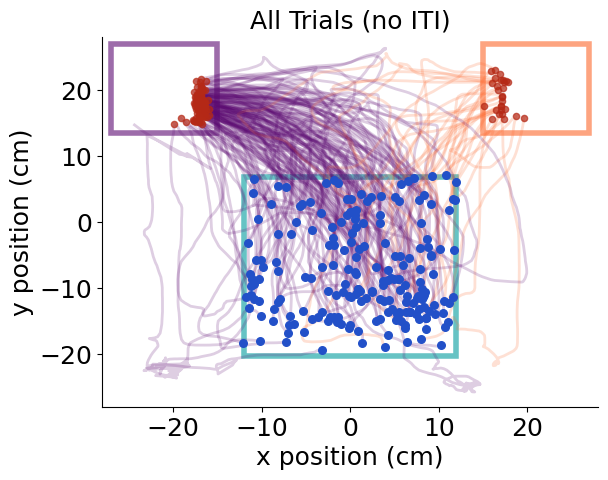

In [37]:
fig, ax1 = plt.subplots()

plotting.plot_session(
    df=df,
    box_df=box_df_output,
    per_aperture=False,
    per_side=True,
    ax=ax1,
)

ax1.set_title("All Trials (no ITI)")
plt.show()

## Display all rewarded trials on left side

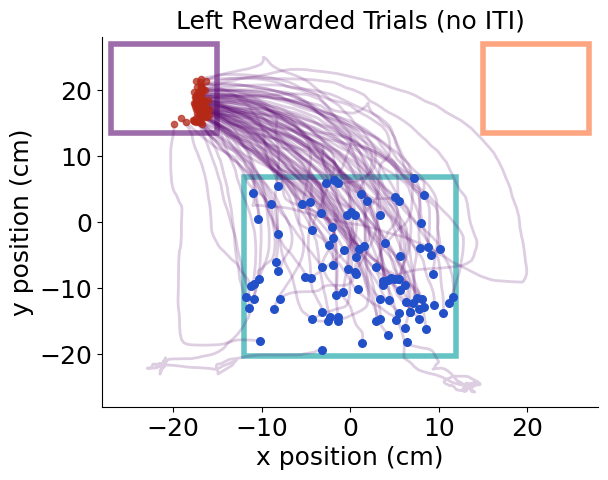

In [38]:
from matplotlib.pyplot import axes


fig, ax2 = plt.subplots()

plotting.plot_session(
    df=df[(df.trial_rewarded == 1) & (df.trial_left_choice == 1)],
    box_df=box_df_output,
    per_aperture=False,
    per_side=True,
    ax=ax2,
)
ax2.set_title("Left Rewarded Trials (no ITI)")
plt.show()

## Display all rewarded trials on right side

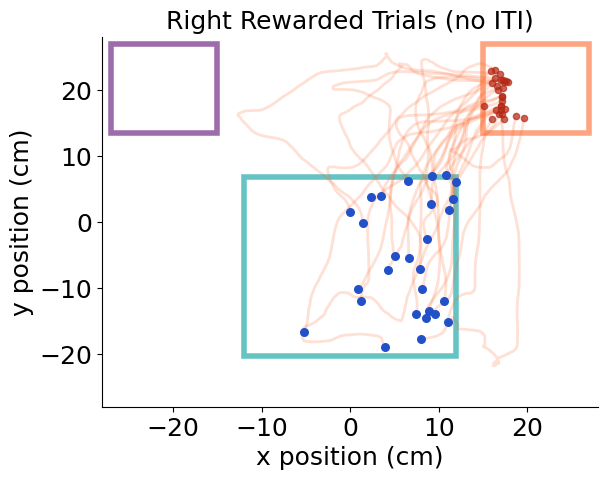

In [39]:
fig, ax3 = plt.subplots()
plotting.plot_session(
    df=df[(df.trial_rewarded == 1) & (df.trial_right_choice == 1)],
    box_df=box_df_output,
    per_aperture=False,
    per_side=True,
    ax=ax3,
)
ax3.set_title("Right Rewarded Trials (no ITI)")
plt.show()

# Display mean trajectory for the j-shaped trials

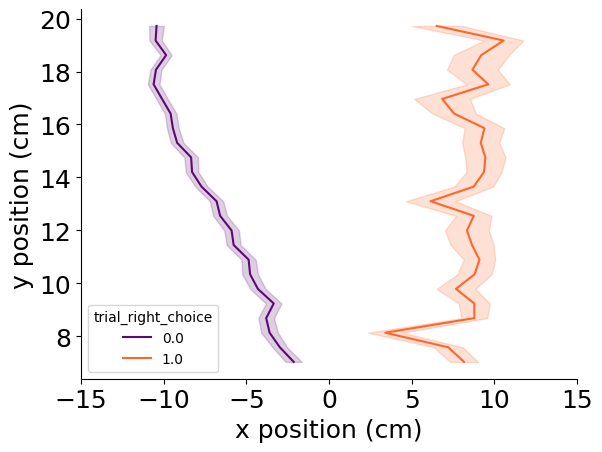

In [41]:
fig, ax10 = plt.subplots()

j_shaped_df = analysis.get_jshaped_trials(df).copy()
j_shaped_df = utils.create_bins(
    data=j_shaped_df, spatial_ybins=[6.75, 20, 25], label="y"
)
plotting.lineplot_flip_axis(
    data=j_shaped_df,
    x="bin_centers",
    y="x",
    hue="trial_right_choice" if num_apertures <= 2 else "aperture",
    palette=plotting.colors_choice if num_apertures <= 2 else "viridis",
    style=None if num_apertures <= 2 else "trial_right_choice",
    errorbar="se",
    ax=ax10,
)
ax10.set_xlim([-15, 15])
ax10.set_ylabel("y position (cm)")
ax10.set_xlabel("x position (cm)")
plt.show()

## Display the choice rate

2026-01-27 10:04:32,299::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-27 10:04:32,299::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-27 10:04:32,306::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-27 10:04:32,306::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-27 10:04:32,327::INFO::category.py::Using categorical un

(0.8391959798994975, nan)


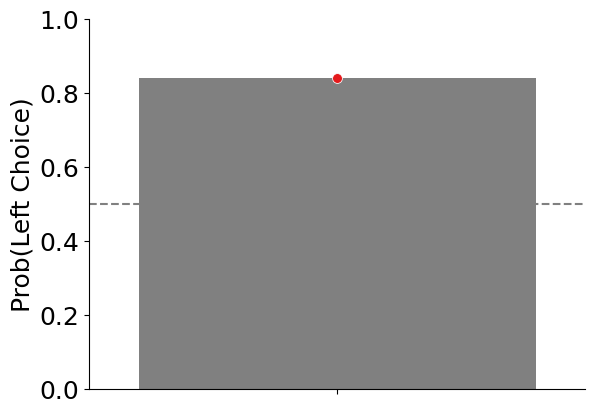

In [42]:
fig, ax4 = plt.subplots()

plotting.plot_rate(
    df=df,
    label_x="trial_left_choice",
    per_aperture=True if num_apertures >= 2 else False,
    ax=ax4,
)
ax4.set_ylabel("Prob(Left Choice)")
ax4.set_ylim([0, 1])
ax4.hlines(0.5, xmin=ax4.get_xlim()[0],
                                 xmax=ax4.get_xlim()[1], 
                                 colors='gray', 
                                 linestyles='dashed')

plt.show()

## Display the target location rate

2026-01-27 10:04:33,831::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-27 10:04:33,831::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-27 10:04:33,838::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-27 10:04:33,838::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-27 10:04:33,873::INFO::category.py::Using categorical un

(0.5175879396984925, nan)


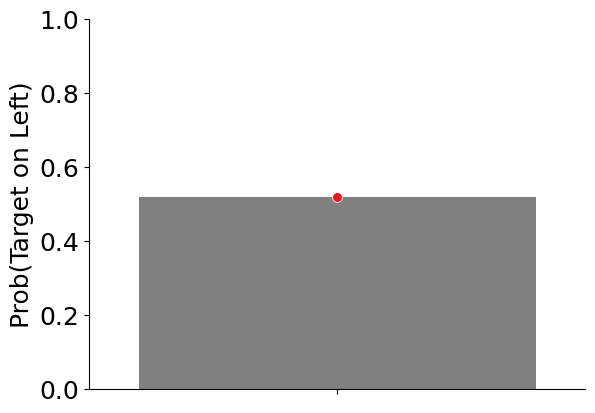

In [43]:
fig, ax5 = plt.subplots()
plotting.plot_rate(
    df=df,
    label_x="object_on_left",
    per_aperture=True if num_apertures >= 2 else False,
    ax=ax5,
)
ax5.set_ylabel("Prob(Target on Left)")
ax5.set_ylim([0, 1])
plt.show()

## Display trial count

2026-01-27 10:04:35,127::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-27 10:04:35,127::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-27 10:04:35,133::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-27 10:04:35,133::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-27 10:04:35,169::INFO::category.py::Using categorical un

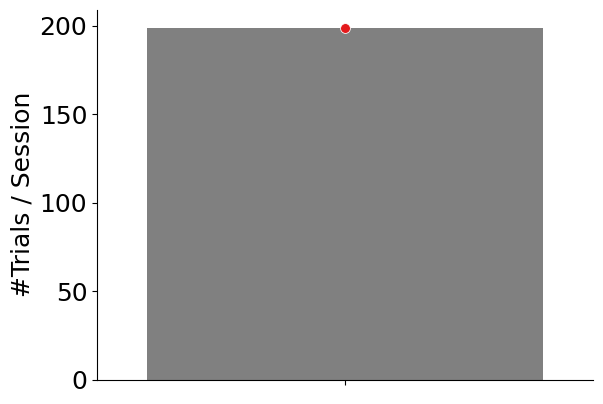

In [44]:
fig, ax6 = plt.subplots()
plotting.plot_trial_count(
    df=df,
    per_aperture=True if num_apertures >= 2 else False,
    ax=ax6,
)
plt.show()

## Display the reward rate

2026-01-27 10:04:37,830::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-27 10:04:37,830::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-27 10:04:37,842::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-27 10:04:37,842::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-27 10:04:37,873::INFO::category.py::Using categorical un

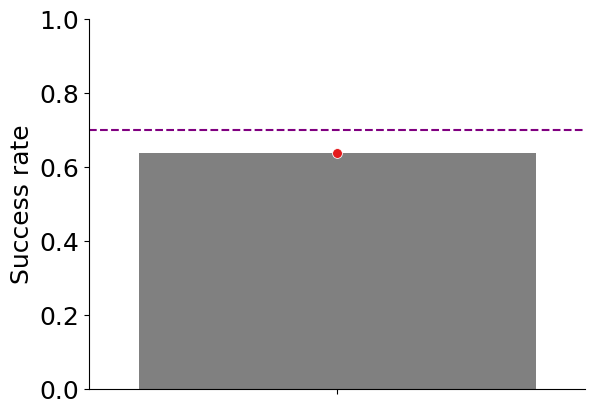

In [45]:
fig, ax7 = plt.subplots()
plotting.plot_rewards(df=df, per_aperture=True if num_apertures >= 2 else False, ax=ax7)
plt.show()

## Display the time to reward 


### per aperture

2026-01-27 10:04:40,511::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-27 10:04:40,511::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-27 10:04:40,516::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-27 10:04:40,516::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
/usr/local/lib/python3.9/dist-packages/matplotlib/axes/_axes.py:

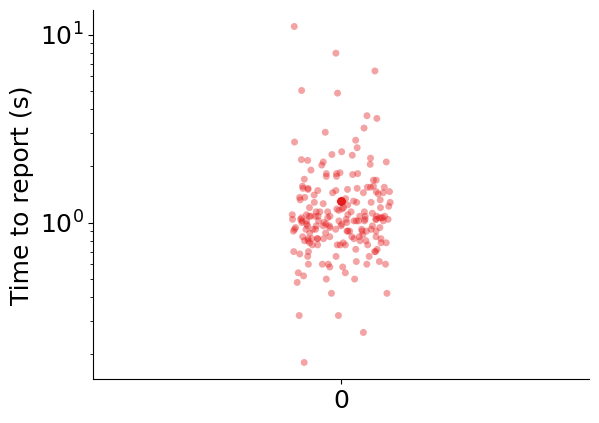

In [46]:
fig, ax = plt.subplots()

plotting.plot_time_to_reward(
    df,
    label_x="aperture",
    xticks=list(df.aperture.unique()),
    ax=ax,
)

plt.show()

### per trial rewarded

2026-01-27 10:04:47,107::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-27 10:04:47,107::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-27 10:04:47,113::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-27 10:04:47,113::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
/usr/local/lib/python3.9/dist-packages/matplotlib/axes/_axes.py:

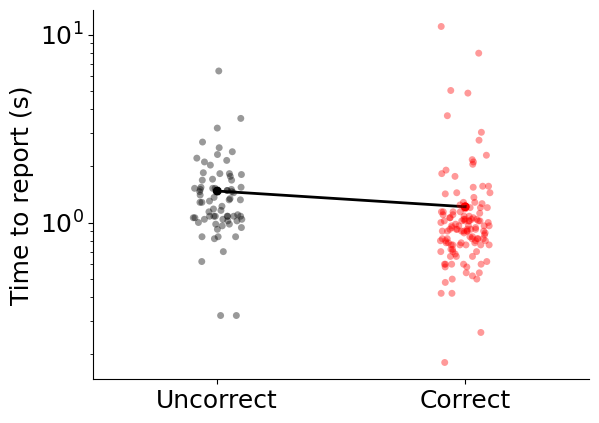

In [ ]:
fig, ax = plt.subplots()

plotting.plot_time_to_reward(
    df,
    label_x="trial_rewarded",
    xticks=["Incorrect", "Correct"],
    ax=ax,
)
plt.show()

###  per choice


2026-01-27 10:04:48,633::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-27 10:04:48,633::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-27 10:04:48,641::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-27 10:04:48,641::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
/usr/local/lib/python3.9/dist-packages/matplotlib/axes/_axes.py:

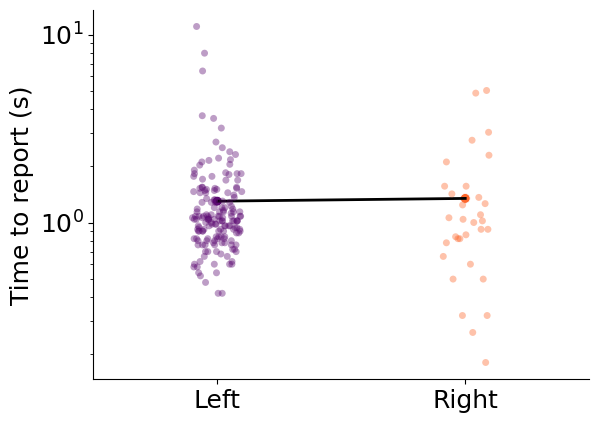

In [49]:
fig, ax = plt.subplots()

plotting.plot_time_to_reward(
    df,
    label_x="trial_right_choice",
    xticks=["Left", "Right"],
    ax=ax,  # time_plots_choice
)

plt.show()

## Interpolation on variable of interest
Note(mary): why it happens here? It's ummary plots... we should plot only here... or create the aditional func

In [50]:
columns = [
    "y",
    "head_dir",
    "trial_tortuosity",
    "trial_duration",
    "x",
    "aperture",
    "velocity",
    "velocity_x",
    "velocity_y",
    "trial_traj_path_length",
    "flip_one_side",
]

interpolated_df = utils.interpolate(
    df,
    n_points=200,
    value_columns=["trial_left_choice", "trial_right_choice", "trial_rewarded"]
    + columns,
)

interpolated_df["trial_step"] = interpolated_df.groupby(
    ["dataset", "trial"]
).trial.cumcount()
interpolated_df["trial_length"] = interpolated_df["trial_step"] / 200

## Display the speed

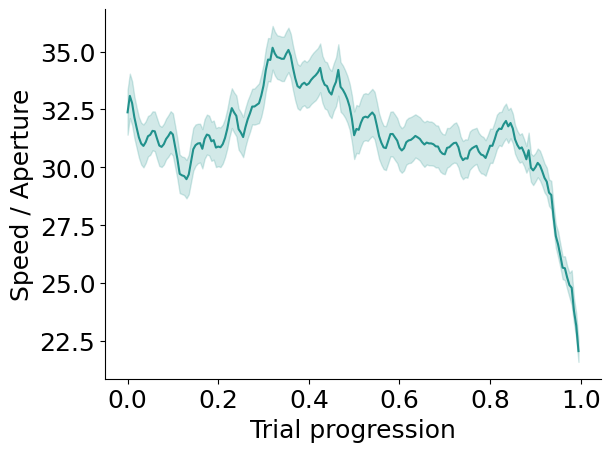

In [51]:
import seaborn as sns

fig, velocity_plot_aperture = plt.subplots()
sns.lineplot(
    data=interpolated_df,
    x="trial_length",
    y="velocity",
    palette=(plotting.colors_aperture[:2] if num_apertures == 2 else "viridis"),
    hue="aperture",
    errorbar="se",
    ax=velocity_plot_aperture,
)
velocity_plot_aperture.legend([], [], frameon=False)
velocity_plot_aperture.set_ylabel("Speed / Aperture")
velocity_plot_aperture.set_xlabel("Trial progression")

plt.show()

## per trial rewarded

Text(0.5, 0, 'Trial progression')

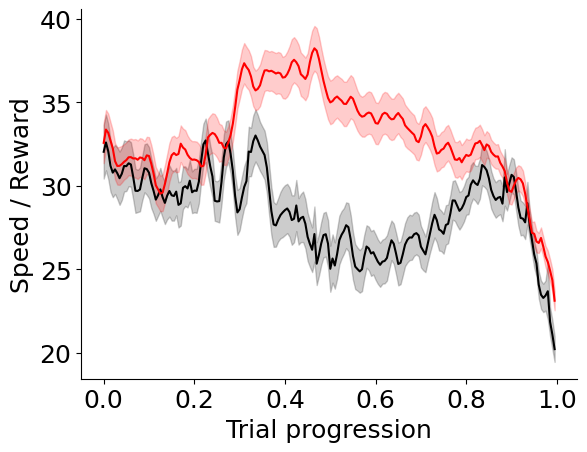

In [52]:
import seaborn as sns

fig, velocity_plot_reward = plt.subplots()
sns.lineplot(
    data=interpolated_df,
    x="trial_length",
    y="velocity",
    palette=plotting.colors_rewarded,
    hue="trial_rewarded",
    errorbar="se",
    ax=velocity_plot_reward,
)
velocity_plot_reward.legend([], [], frameon=False)
velocity_plot_reward.set_ylabel("Speed / Reward")
velocity_plot_reward.set_xlabel("Trial progression")

## per choice

Text(0.5, 0, 'Trial progression')

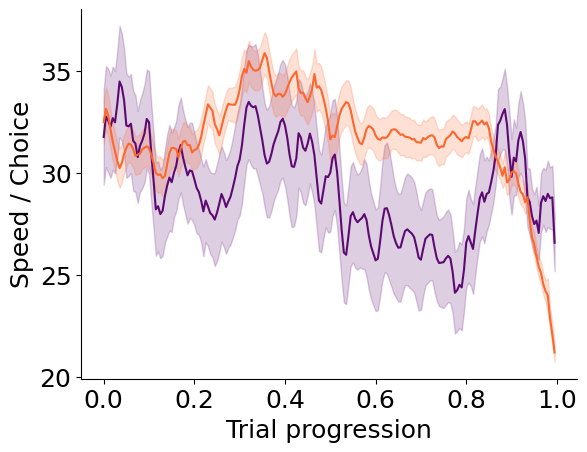

In [53]:
import seaborn as sns

fig, velocity_plot_choice = plt.subplots()

sns.lineplot(
    data=interpolated_df,
    x="trial_length",
    y="velocity",
    palette=plotting.colors_choice,
    hue="trial_left_choice",
    errorbar="se",
    ax=velocity_plot_choice,
)
velocity_plot_choice.legend([], [], frameon=False)
velocity_plot_choice.set_ylabel("Speed / Choice")
velocity_plot_choice.set_xlabel("Trial progression")

## Display heading direction per choice

Text(0.5, 0, 'Trial progression')

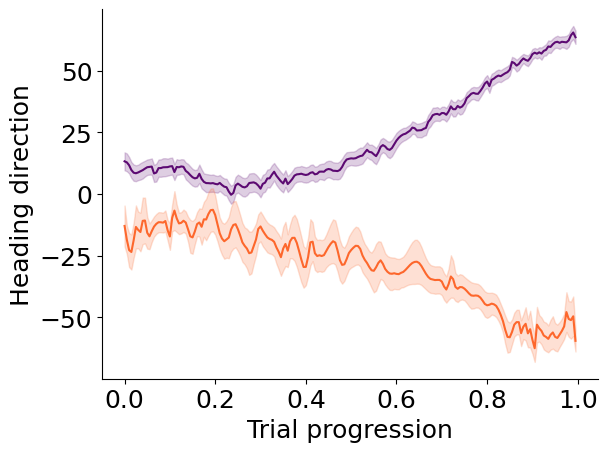

In [54]:
import seaborn as sns

fig, heading_angle_plot = plt.subplots()

sns.lineplot(
    data=interpolated_df,
    x="trial_length",
    y="head_dir",
    hue="trial_right_choice" if num_apertures <= 2 else "aperture",
    palette=plotting.colors_choice if num_apertures <= 2 else "viridis",
    style="aperture" if num_apertures <= 2 else "trial_right_choice",
    errorbar="se",
    ax=heading_angle_plot,
)
heading_angle_plot.legend([], [], frameon=False)
heading_angle_plot.set_ylabel("Heading direction")
heading_angle_plot.set_xlabel("Trial progression")

## Display J-shaped trials rate

2026-01-27 10:05:22,082::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-27 10:05:22,082::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-27 10:05:22,089::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-01-27 10:05:22,089::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-27 10:05:22,132::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-27 10:05:22,132::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-27 10:05:22,137::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-27 10:05:22,137::INFO::category.py::Using categorical un

(0.9748743718592965, nan)


(0.0, 1.0)

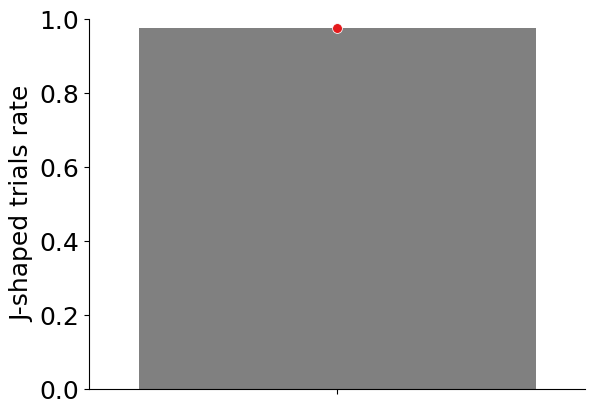

In [55]:
import seaborn as sns

fig, j_shaped_plot = plt.subplots()

plotting.plot_rate(
    df=df,
    label_x="is_j_shaped",
    per_aperture=True if num_apertures >= 2 else False,
    ax=j_shaped_plot,
)
j_shaped_plot.set_ylabel("J-shaped trials rate")
j_shaped_plot.set_ylim([0, 1])

## Display rolling reward

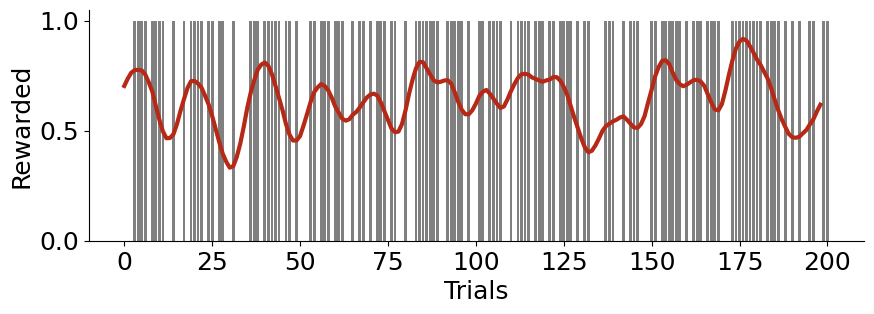

In [62]:
fig, ax8 = plt.subplots(figsize=(10, 3))
plotting.plot_rolling_reward(df, ax=ax8)
plt.show()

## Display rolling choice

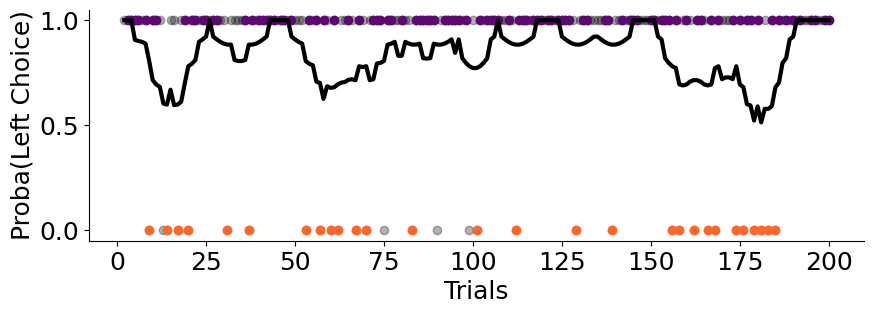

In [63]:
fig, ax9 = plt.subplots(figsize=(10, 3))
plotting.plot_choices_by_trial(df, ax=ax9)
plt.show()